# Move Type Classification Exploration v2

**Objective**: Develop database-driven logic to classify career moves as progression/lateral/cross-functional transitions using JobFunction and ManagementLevel data.

**Database Schema Reference**:
- `jobs` table: JobProfileID, JobFunction, ManagementLevel, JobCategory
- `career_pathways` table: source_job_id, target_job_id, similarity_score
- `positions` table: JobProfileID, Division, Business_Unit

**Key Goal**: Replace manual classification with automated logic based on actual database fields for white paper generation.


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
from pathlib import Path

# Set up database connection
db_path = Path(r"C:\Users\kipjo\OneDrive\Documents\GitHub\skill-similarity-engine\models\2025-Q2\business_context.sqlite")
print(f"Database path: {db_path}")
print(f"Database exists: {db_path.exists()}")

# Connect to database
conn = sqlite3.connect(db_path)
print("✅ Connected to database")

Database path: C:\Users\kipjo\OneDrive\Documents\GitHub\skill-similarity-engine\models\2025-Q2\business_context.sqlite
Database exists: True
✅ Connected to database


## 1. Explore Job Architecture Data

First, let's understand the structure of JobFunction and ManagementLevel data that we'll use for classification.


In [2]:
# Explore jobs table structure
jobs_query = """
SELECT JobProfileID, JobProfile, JobFunction, ManagementLevel, JobCategory,
       Customer_Facing, is_Banker, Executive_Leadership_Group
FROM jobs 
LIMIT 10
"""

jobs_sample = pd.read_sql_query(jobs_query, conn)
print("📋 Sample Jobs Data:")
display(jobs_sample)

print("\n📊 Jobs Table Statistics:")
total_jobs = pd.read_sql_query('SELECT COUNT(*) as count FROM jobs', conn)['count'][0]
print(f"Total jobs: {total_jobs}")


📋 Sample Jobs Data:


,JobProfileID,JobProfile,JobFunction,ManagementLevel,JobCategory,Customer_Facing,is_Banker,Executive_Leadership_Group
0,R0001.5,Payment Systems Analyst - 5,Data & Analytics,Group 2,Support,Customer Facing,Non-Banker,
1,R0001.6,Settlement Officer - 6,Data & Analytics,Group 1,Support,Customer Facing,Banker,Executive Leadership Group
2,R0002.0,Sales Manager - II,Banking Services,Group 4,Enabling,Customer Facing,Banker,
3,R0002.1,Sales Manager - 1,Security & Fraud,Group 2,Revenue Generating,Customer Facing,Banker,
4,R0002.2,Relationship Manager - 2,Investment Management,Group 3,Enabling,Customer Facing,Banker,
5,R0002.3,Customer Service Representative - 3,Facilities & Administration,Group 3,Revenue Generating,Non-Customer Facing,Banker,
6,R0002.4,Customer Service Representative - 4,Security & Fraud,Group 3,Revenue Generating,Customer Facing,Banker,
7,R0003.0,Cloud Architect - 0,Data & Analytics,Group 2,Enabling,Customer Facing,Non-Banker,
8,R0003.2,Digital Product Manager - III,Risk Management,Group 6,Enabling,Non-Customer Facing,Non-Banker,
9,R0005.1,Business Banker - 1,Customer Relations,Group 2,Support,Customer Facing,Non-Banker,



📊 Jobs Table Statistics:
Total jobs: 715


🏢 JobFunction Distribution:


,JobFunction,count
0,Operations & Processing,78
1,Risk Management,55
2,Finance & Treasury,54
3,Facilities & Administration,51
4,Banking Services,45
5,Investment Management,44
6,Data & Analytics,41
7,Technology & Engineering,36
8,Marketing & Communications,35
9,Research & Analysis,33


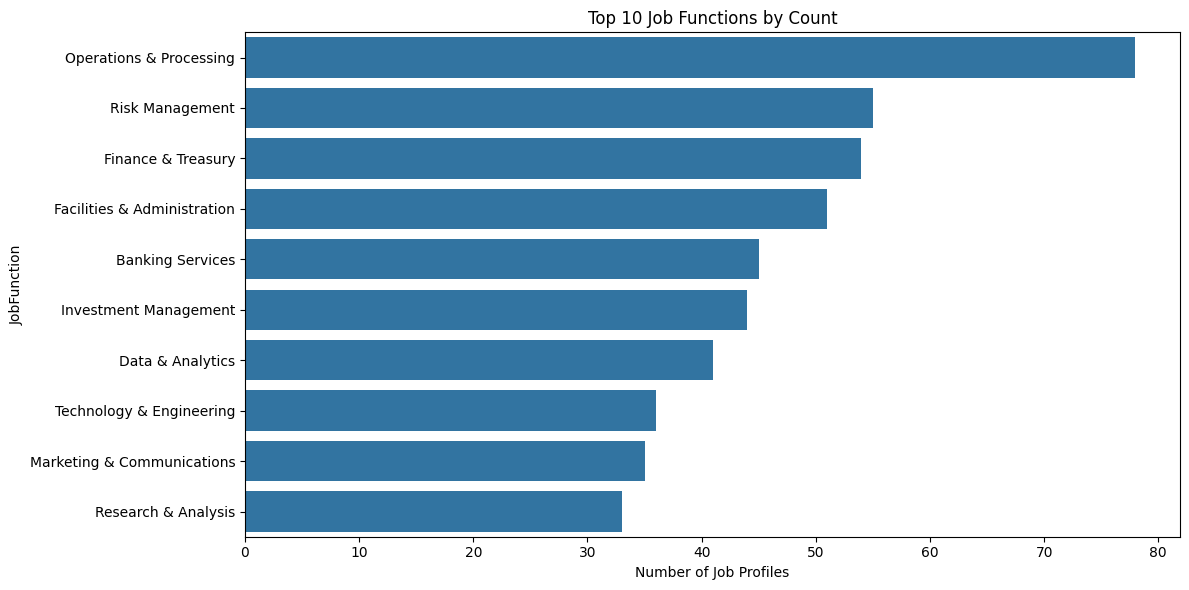

In [3]:
# Analyze JobFunction distribution
job_functions = pd.read_sql_query("""
SELECT JobFunction, COUNT(*) as count
FROM jobs 
WHERE JobFunction IS NOT NULL
GROUP BY JobFunction 
ORDER BY count DESC
""", conn)

print("🏢 JobFunction Distribution:")
display(job_functions)

# Visualize JobFunction distribution
plt.figure(figsize=(12, 6))
sns.barplot(data=job_functions.head(10), x='count', y='JobFunction')
plt.title('Top 10 Job Functions by Count')
plt.xlabel('Number of Job Profiles')
plt.tight_layout()
plt.show()


In [ ]:
# Quick test to verify the function works with the hierarchy_map from previous cell
print("🔍 Quick function verification...")

# Test if hierarchy_map is available and function works
if 'hierarchy_map' in locals():
    print("✅ hierarchy_map is available")
    # Test the function
    test_result = classify_move_type("Technology", "Group 3", "Technology", "Group 4", hierarchy_map)
    print(f"✅ Function test result: {test_result}")
else:
    print("❌ hierarchy_map not found - make sure to run cell 5 first")
    print("Available variables:", [var for var in locals().keys() if not var.startswith('_')])


📊 ManagementLevel Distribution:


,ManagementLevel,count
0,Group 2,173
1,Group 3,137
2,Group 4,127
3,Group 1,123
4,Group 5,78
5,Group 6,44
6,Group 7,20
7,Group NA,13


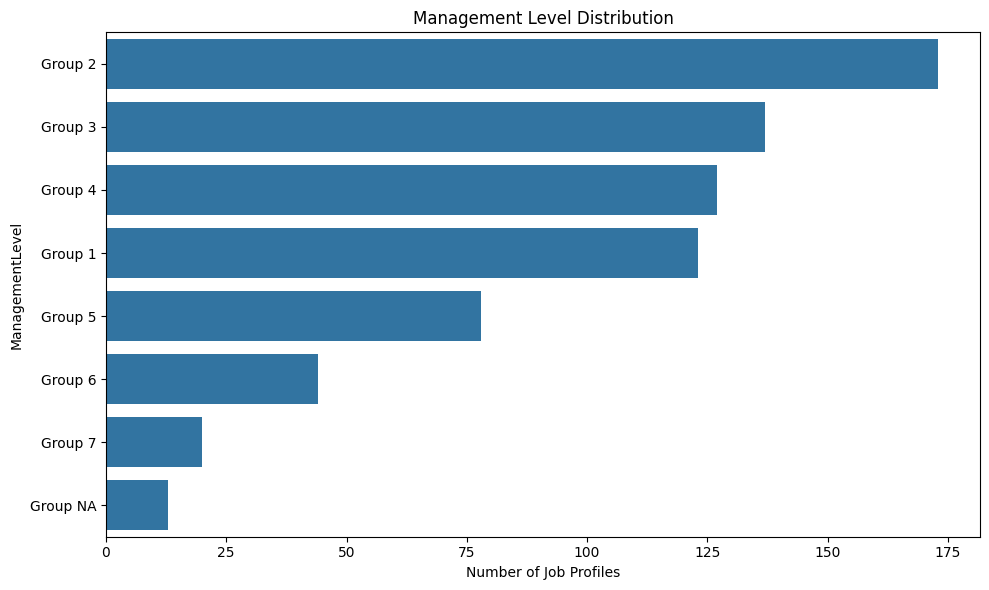

In [4]:
# Analyze ManagementLevel distribution
management_levels = pd.read_sql_query("""
SELECT ManagementLevel, COUNT(*) as count
FROM jobs 
WHERE ManagementLevel IS NOT NULL
GROUP BY ManagementLevel 
ORDER BY count DESC
""", conn)

print("📊 ManagementLevel Distribution:")
display(management_levels)

# Visualize ManagementLevel distribution
plt.figure(figsize=(10, 6))
sns.barplot(data=management_levels, x='count', y='ManagementLevel')
plt.title('Management Level Distribution')
plt.xlabel('Number of Job Profiles')
plt.tight_layout()
plt.show()


## 2. Create Management Level Hierarchy

Define a hierarchy mapping for management levels to enable progression analysis.


In [5]:
# Create management level hierarchy mapping
def create_management_hierarchy():
    """
    Create a hierarchy mapping for management levels.
    Higher numbers = higher seniority
    """
    hierarchy_map = {
        'Group NA': 0,  # Non-management or unclear
        'Group 1': 1,   # Entry level
        'Group 2': 2,   # Junior
        'Group 3': 3,   # Mid-level
        'Group 4': 4,   # Senior
        'Group 5': 5,   # Principal/Lead
        'Group 6': 6,   # Manager
        'Group 7': 7,   # Senior Manager/Director
    }
    return hierarchy_map

hierarchy_map = create_management_hierarchy()
print("📊 Management Level Hierarchy:")
for level, rank in hierarchy_map.items():
    print(f"  {level}: {rank}")

# Test hierarchy with actual database data
hierarchy_validation = pd.read_sql_query("""
SELECT ManagementLevel, COUNT(*) as count,
       CASE 
           WHEN ManagementLevel = 'Group NA' THEN 0
           WHEN ManagementLevel = 'Group 1' THEN 1
           WHEN ManagementLevel = 'Group 2' THEN 2
           WHEN ManagementLevel = 'Group 3' THEN 3
           WHEN ManagementLevel = 'Group 4' THEN 4
           WHEN ManagementLevel = 'Group 5' THEN 5
           WHEN ManagementLevel = 'Group 6' THEN 6
           WHEN ManagementLevel = 'Group 7' THEN 7
           ELSE 0 END as hierarchy_rank
FROM jobs 
GROUP BY ManagementLevel 
ORDER BY hierarchy_rank
""", conn)

print("\n🔍 Hierarchy Validation with Database Data:")
display(hierarchy_validation)


📊 Management Level Hierarchy:
  Group NA: 0
  Group 1: 1
  Group 2: 2
  Group 3: 3
  Group 4: 4
  Group 5: 5
  Group 6: 6
  Group 7: 7

🔍 Hierarchy Validation with Database Data:


,ManagementLevel,count,hierarchy_rank
0,Group NA,13,0
1,Group 1,123,1
2,Group 2,173,2
3,Group 3,137,3
4,Group 4,127,4
5,Group 5,78,5
6,Group 6,44,6
7,Group 7,20,7


## 3. Define Move Type Classification Function

Create the core function to classify career moves based on JobFunction and ManagementLevel changes.


In [6]:
def classify_move_type(source_function, source_level, target_function, target_level, hierarchy_map):
    """
    Classify career move type based on JobFunction and ManagementLevel changes.
    
    Args:
        source_function: Source job's JobFunction
        source_level: Source job's ManagementLevel  
        target_function: Target job's JobFunction
        target_level: Target job's ManagementLevel
        hierarchy_map: Dictionary mapping ManagementLevel to numeric hierarchy
    
    Returns:
        tuple: (move_type, subtype, level_change)
    """
    
    # Get hierarchy ranks (default to 0 if not found)
    source_rank = hierarchy_map.get(source_level, 0)
    target_rank = hierarchy_map.get(target_level, 0)
    level_change = target_rank - source_rank
    
    # Determine if functions are the same
    same_function = source_function == target_function
    
    # Classify move type
    if level_change > 0:
        # Upward movement
        if same_function:
            move_type = "Progression"
            subtype = "Functional_Advancement"
        else:
            move_type = "Progression" 
            subtype = "Cross_Functional_Advancement"
    
    elif level_change < 0:
        # Downward movement (treat as lateral for career planning)
        if same_function:
            move_type = "Lateral"
            subtype = "Functional_Transition"
        else:
            move_type = "Lateral"
            subtype = "Cross_Functional_Transition"
    
    else:
        # Same level
        if same_function:
            move_type = "Lateral"
            subtype = "Role_Variation"
        else:
            move_type = "Lateral"
            subtype = "Cross_Functional_Lateral"
    
    return move_type, subtype, level_change

print("✅ Move type classification function defined!")


✅ Move type classification function defined!


In [7]:
# Test the function with sample data
print("🧪 Testing classification function...")

test_cases = [
    ("Technology", "Group 3", "Technology", "Group 4", "Progression within same function"),
    ("Risk Management", "Group 2", "Technology", "Group 3", "Cross-functional progression"),
    ("Technology", "Group 4", "Technology", "Group 4", "Lateral within same function"),
    ("Risk Management", "Group 3", "Finance", "Group 3", "Cross-functional lateral"),
    ("Technology", "Group 4", "Technology", "Group 2", "Functional transition (downward)")
]

for source_func, source_lvl, target_func, target_lvl, description in test_cases:
    move_type, subtype, level_change = classify_move_type(
        source_func, source_lvl, target_func, target_lvl, hierarchy_map
    )
    print(f"📋 {description}:")
    print(f"   Move Type: {move_type}, Subtype: {subtype}, Level Change: {level_change}")
    print()

print("✅ Function testing complete!")


🧪 Testing classification function...
📋 Progression within same function:
   Move Type: Progression, Subtype: Functional_Advancement, Level Change: 1

📋 Cross-functional progression:
   Move Type: Progression, Subtype: Cross_Functional_Advancement, Level Change: 1

📋 Lateral within same function:
   Move Type: Lateral, Subtype: Role_Variation, Level Change: 0

📋 Cross-functional lateral:
   Move Type: Lateral, Subtype: Cross_Functional_Lateral, Level Change: 0

📋 Functional transition (downward):
   Move Type: Lateral, Subtype: Functional_Transition, Level Change: -2

✅ Function testing complete!
